# CAT Bond Tutorial

In this tutorial we create and evaluate our own parametric souvereign CAT bonds. A more detailed description of how the CAT bonds are created is included in the paper "Lowering premiums and increasing investor returns by issuing multi-country CAT bonds" which is published as a preprint ([http://dx.doi.org/10.2139/ssrn.6030454]). To create the CAT bonds we will perform the following steps: 
1. Define exposure, hazard and vulnerability for each country which should be protected by a CAT bond.
2. Define the attachment (minimum payout) and exhaustion point (maximum payout = principal).
3. Devide the exposed area of each country into subareas. Each subarea will have its own payout function which uses the hazard intensity to derive the final payout based on a linear scale between the minimum and maximum payout. 
4. Calculate the expected damage for each hazard event and subarea in the simulation period. Use the expected damage per subarea per event to calibrate the payout functions per subarea. 
5. Simulate the losses of the bonds based on the payouts per hazard event. 
5. Calculate the premiums for the bond. We use three different methods: 
    - Benchmark Pricing: Premiums are set to achieve a predefined sharpe ratio.
    - Chatoro-Pricing: Based on Chatoro et al. ([https://doi.org/10.1016/j.irfa.2022.102431]) we derive the premiums based on the expected loss of our CAT bond and current market conditions. 
    - IBRD-Pricing: Based on the risk multiple (expected loss / annual premium rate) of previously issued parametric sovereign CAT bonds from the World Bank.
6. Simulate the net cash flow of the bond based on the premiums and the losses. 

<br><br>
Additionally to the single-country CAT bonds we will also create multi-country CAT bonds. For this we: 
1. Derive optimal pools using minimum risk diversification as the objective (as proposed by Ciullo et al. ([https://doi.org/10.1038/s41467-023-36539-4])). For this we set the constraint as: 
    - a fixed number of non-empty pools has to be created
    - a maximum principal is not allowed to be exceeded per multi-country CAT bond
2. Calculate the minimum principal necessary, so that the multi-country CAT bond covers all damages equally as the single-country CAT bonds.
3. Once this is done, the losses are simulated, the premiums calculated and the net cash flow is derived. 

### Import packages

In [ ]:
%load_ext autoreload
%autoreload 2
# import standard packages
from datetime import date

# import CAT bond module parts from CLIMADA-PETALS
from climada_petals.engine.cat_bonds.subareas import Subareas
from climada_petals.engine.cat_bonds.subarea_calculations import SubareaCalculations
from climada_petals.engine.cat_bonds.sng_bond_simulation import SingleCountryBondSimulation
from climada_petals.engine.cat_bonds.mlt_bond_simulation import MultiCountryBond
from climada_petals.engine.cat_bonds.premium_class import PremiumCalculations
from climada_petals.engine.cat_bonds.helpers_tutorial_cat_bonds import create_earthquake_mmi_impact_function, remap_event_years_even

# import CLIMADA core modules
from climada.entity import ImpfSetTropCyclone
from climada.util.api_client import Client
client = Client()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set CAT Bond Basic Settings

We first need to set the basics for the creation of CAT bonds. This includes: 
1. Exhaustion point (Exposure_Share (set as share) or Return_Period (set as years) or None (-> set in the unit of the exposure layer)).
2. Attachment point (Exposure_Share (set as share) or Return_Period (set as years) or None (-> set in the unit of the exposure layer)).
3. Term of the bond in years.
4. Start year of the bond simulation.
5. Number of terms to simulate.
6. The parametric index statistic (either a float which is used to calculate percentiles of hazard intensity in each subarea or a string called 'mean' which calculates the average of the hazard intensity in each subarea).
7. Resolution for the creation of subareas. Has to be set for each country. Don't set them to small or you will end up with too many suabreas which slows down computation.
8. Define wether your CAT bond is considered peak or multi peril, has a hybrid trigger and if it is investment graded.
9. Target sharpe ratio which has to be met by setting premiums accordingly.

In [57]:
### Bond Basics ###
countries = [659, 388, 822]  # St. Kitts and Nevis, Jamaica, Samoa
exhaustion_point = 0.5 # principal should be 50% of exposure 
attachment_point = 0.05 # minimum payout should be 5% of exposure
exhaustion_point_method = 'Exposure_Share' # could also be "Return_Period" or None
attachment_point_method = 'Exposure_Share' # could also be "Return_Period" or None
term = 3  # term of bond in years
start_year = 1980 # start year for simulation
num_of_terms = 1000 // term # number of terms to simulate
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
resolution_samoa = 0.5 # resolution used to derive subareas for Samoa
resolution_jamaica = 0.5 # resolution used to derive subareas for Jamaica
resolution_st_kitts = 0.05 # resolution used to derive subareas for St. Kitts and Nevis

### Pricing Basics ###
peak_peril = 0 # indicator if bond is considered peak/multi peril (1) or not (0)
hybrid_trigger = 0 # indicator if bond contains a hybrid trigger (1) or not (0)
investment_graded = 0 # indicator if bond is investment graded (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio for benchmark pricing 

As you can see we will create CAT bonds for St. Kitts and Nevis, Jamaica and Samoa. For each country the attachment point will equal 5% of the exposure and the exhaustion point 50%. Check the other parameters for the simulation, subarea, and pricing settings. 

The starting date for the simulation of the CAT bond will be in 1980. The term will be set to 3 years, a common value for CAT bonds.  Our hazard data covers 1000 years of tropical cyclone events, therefore, the number of terms to simulate will be 333, which results in the simulation of 999 years.

## Define Exposure, Hazard, and Vulnerability per Country

For each country in the list we first define exposure, hazard and vulnerability. 
1. Hazard: For each country we import tropical cyclone hazard data sets from the CLIMADA data API, based on STORM [https://www.science.org/doi/10.1126/sciadv.abm8438]. This dataset contains synthetic TC trakc covering a 1000 year period. Please be aware that the assinged dates for the hazard events matter for the CAT bond simulation. It may be necessary to assign realistic dates to each event, depending on what hazard data set you use.
2. Exposure: LitPop objects constructed using the countries GDP from 2020 as total asset value which is then disaggregated proportional to a combination of nightlight intensity and gridded population data. 
3. Vulnerability: Functions are taken from Eberenz et al. 2021: [https://doi.org/10.5194/nhess-21-393-2021] which have calibrated regional TC wind impact functions.

In [ ]:
### GET HAZARD ###
# get hazard for jamaica
hazard_jamaica = client.get_hazard(
    "tropical_cyclone",
    properties={
        "event_type": "synthetic",
        "model_name": "STORM",
        "country_name": "Jamaica",
        "climate_scenario": None
    },
)

# get hazard for st. kitts and nevis
hazard_st_kitts = client.get_hazard(
    "tropical_cyclone",
    properties={
        "event_type": "synthetic",
        "model_name": "STORM",
        "country_iso3alpha": "KNA",
        "climate_scenario": None
    },
)

# get hazard for samoa
hazard_samoa = client.get_hazard(
    "tropical_cyclone",
    properties={
        "event_type": "synthetic",
        "model_name": "STORM",
        "country_name": "Samoa",
        "climate_scenario": None
    },
)

#adjust dates of hazard data sets -> the assigned year for each event in the STORM TC hazard data sets from the CLIMADA data API is 1980. 
# As the simulation of CAT bonds depends on the distribution of events over time, we need to remap the event years for each hazard data set.
# Here, we remap the event years to be evenly distributed over a period of 1000 years starting from the defined start year (1980). 
hazard_jamaica = remap_event_years_even(hazard_jamaica, start_year=start_year, n_years=1000)
hazard_st_kitts = remap_event_years_even(hazard_st_kitts, start_year=start_year, n_years=1000)
hazard_samoa = remap_event_years_even(hazard_samoa, start_year=start_year, n_years=1000)

### GET EXPOSURE ###
exp_jamaica = client.get_litpop('JAM') # get exposure for jamaica
exp_samoa = client.get_litpop('WSM') # get exposure for samoa
exp_st_kitts = client.get_litpop('KNA') # get exposure for st. kitts and nevis
exp_jamaica.gdf['impf_TC'] = 1 # map impact function ID for Jamaica-> Region North America 
exp_samoa.gdf['impf_TC'] = 4 # map impact function ID for Samoa -> Region Oceania
exp_st_kitts.gdf['impf_TC'] = 1 # map impact function ID for st. kitts and nevis -> Region North America 1

### GET IMPACT FUNCTION ###
impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet() # get impact function for tropical cyclone

2026-05-01 13:16:37,395 - climada.hazard.io - INFO - Reading C:\Users\Kai\climada\data\hazard\tropical_cyclone\TC_JAM_0300as_STORM\v1.1\TC_JAM_0300as_STORM.hdf5
2026-05-01 13:16:44,157 - climada.hazard.io - INFO - Reading C:\Users\Kai\climada\data\hazard\tropical_cyclone\TC_KNA_0300as_STORM\v1.1\TC_KNA_0300as_STORM.hdf5
2026-05-01 13:16:50,744 - climada.hazard.io - INFO - Reading C:\Users\Kai\climada\data\hazard\tropical_cyclone\TC_WSM_0300as_STORM\v1.1\TC_WSM_0300as_STORM.hdf5
2026-05-01 13:17:05,885 - climada.entity.exposures.base - INFO - Reading C:\Users\Kai\climada\data\exposures\litpop\LitPop_150arcsec_JAM\v3\LitPop_150arcsec_JAM.hdf5
2026-05-01 13:17:07,158 - climada.entity.exposures.base - INFO - Reading C:\Users\Kai\climada\data\exposures\litpop\LitPop_150arcsec_WSM\v3\LitPop_150arcsec_WSM.hdf5
2026-05-01 13:17:08,421 - climada.entity.exposures.base - INFO - Reading C:\Users\Kai\climada\data\exposures\litpop\LitPop_150arcsec_KNA\v3\LitPop_150arcsec_KNA.hdf5


## Initialise Subareas Class

Now we actually start to create a CAT bond. First, we create an instance of the Subareas class for each country which stores the subareas of the resulting CAT bonds. Note: The subarea class can also be generated with an geodataframe. Then the subareas are not calculated from the resolution but from the given geodataframe. Be sure that the given subareas cover the entire area exposed. 

2026-05-01 13:17:59,907 - climada_petals - INFO - Rasterizing exposure with width: 4, height: 5, resolution: 0.05
2026-05-01 13:17:59,947 - climada_petals - INFO - Exposure perimeter polygon created.
2026-05-01 13:17:59,950 - climada_petals - INFO - Number of polygons in exposure perimeter: 2
2026-05-01 13:17:59,984 - climada_petals - INFO - Merging overlapping grid cells into single polygons.
2026-05-01 13:18:00,033 - climada_petals - INFO - Subareas created.
2026-05-01 13:18:00,051 - climada_petals - INFO - Rasterizing exposure with width: 42, height: 15, resolution: 0.05


c:\Users\Kai\miniforge3\envs\climada_env\Lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


2026-05-01 13:18:00,289 - climada_petals - INFO - Exposure perimeter polygon created.
2026-05-01 13:18:00,289 - climada_petals - INFO - Number of polygons in exposure perimeter: 1
2026-05-01 13:18:00,444 - climada_petals - INFO - Merging overlapping grid cells into single polygons.
2026-05-01 13:18:00,489 - climada_petals - INFO - Subareas created.
2026-05-01 13:18:00,502 - climada_petals - INFO - Rasterizing exposure with width: 25, height: 10, resolution: 0.05
2026-05-01 13:18:00,591 - climada_petals - INFO - Exposure perimeter polygon created.
2026-05-01 13:18:00,593 - climada_petals - INFO - Number of polygons in exposure perimeter: 2
2026-05-01 13:18:00,599 - climada_petals - INFO - Polygon smaller than resolution; adding polygon bounding box.
2026-05-01 13:18:00,607 - climada_petals - INFO - Polygon smaller than resolution; adding polygon bounding box.
2026-05-01 13:18:00,624 - climada_petals - INFO - Merging overlapping grid cells into single polygons.


c:\Users\Kai\miniforge3\envs\climada_env\Lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
c:\Users\Kai\miniforge3\envs\climada_env\Lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


2026-05-01 13:18:00,685 - climada_petals - INFO - Subareas created.
2026-05-01 13:18:00,691 - climada.util.coordinates - INFO - Raster from resolution 0.04166665999999708 to 0.04166665999999708.


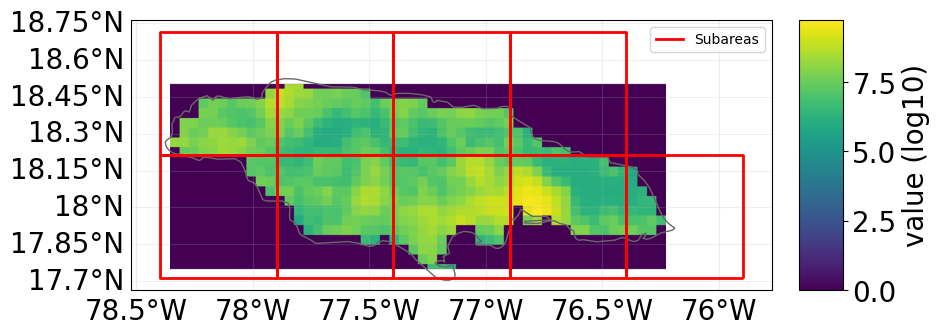

2026-05-01 13:18:44,199 - climada.util.coordinates - INFO - Raster from resolution 0.04166665999999708 to 0.04166665999999708.


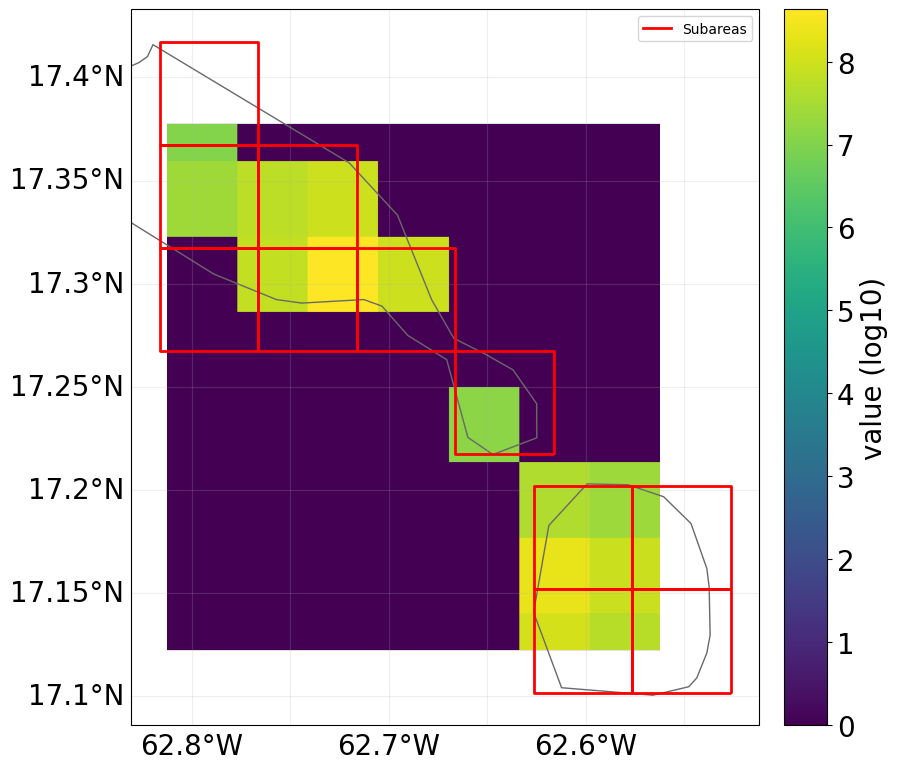

2026-05-01 13:19:21,353 - climada.util.coordinates - INFO - Raster from resolution 0.041666659999975764 to 0.041666659999975764.


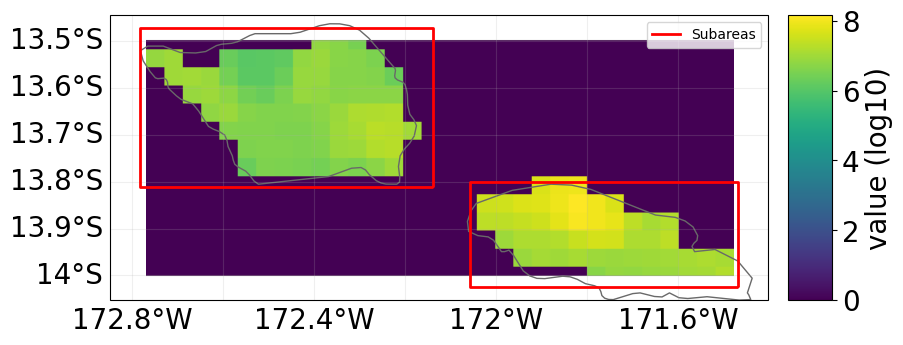

In [58]:
st_kitts_subareas = Subareas.from_resolution(hazard_st_kitts, impfset, exp_st_kitts, resolution=resolution_st_kitts) # derive subareas for St. Kitts and Nevis
jamaica_subareas = Subareas.from_resolution(hazard_jamaica, impfset, exp_jamaica, resolution=resolution_jamaica) # derive subareas for Jamaica
samoa_subareas = Subareas.from_resolution(hazard_samoa, impfset, exp_samoa, resolution=resolution_samoa) # derive subareas for Samoa
# Plot subareas per CAT bond
jamaica_subareas.plot()
st_kitts_subareas.plot()
samoa_subareas.plot()

We can now see for each country the distribution of exposed assets as well as the subareas (red rectangles) covering the countries. Each country is divided by a different number of subareas depending on the chosen resolution and country size.

## Subarea Calculations

Based on the Subareas class and the generated subareas per CAT bond we can now derive the setups for each bond with the SubareaCalculations class. We first initialise the class and then calculate the payout vs damage dataframe. This dataframe contains for each hazard event given to the Subarea class, the damage and the payout and stores information on the hazard event year and month. 
In order to be able to create this dataframe the following computations are performed when calling the method create_pay_vs_dam(): 
1. Calculate the initial guess for the payout function optimization if it is not given with class initialization. 
2. Calculate the damage per hazard event per subarea. 
3. Derive the attachment and exhaustion point (principal) if not given as a monteary value (exhaustion/attachment_point_method == None). 
4. Optimize the payout functions per subarea. 
5. Calculate the payouts per event and subarea. 
6. Return the final payout vs damage dataframe.
Please review the logging messages for the attachment/exhaustion points and check the pay_vs_dam dataframes per CAT bond to get a feeling for the data.

In [59]:
st_kitts_sub_calc = SubareaCalculations(subareas=st_kitts_subareas, index_stat=par_index) # initialize subarea calculations for St. Kitts and Nevis
jamaica_sub_calc = SubareaCalculations(subareas=jamaica_subareas, index_stat=par_index) # initialize subarea calculations for Jamaica
samoa_sub_calc = SubareaCalculations(subareas=samoa_subareas, index_stat=par_index) # initialize subarea calculations for Samoa
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for St. Kitts and Nevis
jamaica_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for Jamaica
samoa_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for Samoa

2026-05-01 13:20:02,980 - climada_petals - INFO - Calculating impact and subarea-level impacts per event.
2026-05-01 13:20:02,990 - climada.entity.exposures.base - INFO - Matching 14 exposures with 2 centroids.
2026-05-01 13:20:03,000 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2026-05-01 13:20:03,017 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 712800 events.
2026-05-01 13:20:03,517 - climada_petals - INFO - Calculating parametric index per subarea.
2026-05-01 13:20:05,873 - climada_petals - INFO - The attachment point and the principal of the CAT bond is: 67258571.85 and 672585718.5 [USD], respectively.
2026-05-01 13:20:05,875 - climada_petals - INFO - Calibrating payout functions by optimizing trigger thresholds to minimize basis risk.
2026-05-01 13:20:12,630 - climada_petals - INFO - Calculating pay-versus-damage table for all events using optimized

## Single-Country CAT Bond Simulation

1. Now we can simulate the losses of the bonds. For this we create an instance of the SingleCountryBondSimulation per CAT bond. Each object needs information on the term of the bond (given in years) and the number of terms to simulate. Afterwards we can call the method init_loss_simulation() per CAT bond object
2. With the information on the losses per bond (given as a dataframe containing the relative loss, month + year per loss) we can derive the annual premium rates by creating an instance of the PremiumCalculations class and then using the desired premium calculation methods. This module contains three different possibilities to derive premiums: 
    - calc_chatoro_premium() (Chatoro et al. ([https://doi.org/10.1016/j.irfa.2022.102431]) premium)
    - calc_ibrd_premium() (World Bank CAT bonds based premium)
    - calc_benchmark_premium() (Target sharpe ration premium)
3. Given the annual premium rates we can calculate the net cash flows and premium payments of each bond with init_return_simulation(). Premiums are paid at the first of each month relative to the remaining principal of the bond. The simulation is performed for one of the three derived premium rates. Premium rates can also be defined manually if desired. 
4. Inspect the metrics of the bond. 

In [60]:
### ST. KITTS AND NEVIS BOND SIMULATION ###
st_kitts_bond_sim = SingleCountryBondSimulation(subarea_calc=st_kitts_sub_calc, term=term, start_year=start_year, number_of_terms=num_of_terms) # initialize bond simulation for St. Kitts and Nevis
st_kitts_bond_sim.init_loss_simulation() # derive loss simulation for St. Kitts and Nevis
st_kitts_premiums = PremiumCalculations(bond_simulation_class=st_kitts_bond_sim) # initialize premium calculations for St. Kitts and Nevis
st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for St. Kitts and Nevis
st_kitts_premiums.calc_ibrd_premium() # derive IBRD premium for St. Kitts and Nevis
st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for St. Kitts and Nevis using target sharpe ratio
st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate) # simulate returns for St. Kitts and Nevis using Chatoro premium
display(st_kitts_bond_sim.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}%")

2026-05-01 13:21:00,529 - climada_petals - INFO - Expected Loss = 0.04244080553734771
2026-05-01 13:21:00,529 - climada_petals - INFO - Attachment Probability = 0.0940940940940941
2026-05-01 13:21:00,589 - climada_petals - INFO - Using default GCIndex value of 180
2026-05-01 13:21:00,590 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-05-01 13:21:00,591 - climada_petals - INFO - Calculated Chatoro premium rate: 0.1200875106245345
2026-05-01 13:21:00,661 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.0575743650981355, k=0.6461612968444108, b=1.5306263398727946
2026-05-01 13:21:00,663 - climada_petals - INFO - Calculated IBRD premium rate: 0.07605424523337957


{'Expected_annual_loss': 0.04244080553734771,
 'Annual_attachment_probability': 0.0940940940940941,
 'Total_payout': 28516534606.369743,
 'Total_damages': 284652715459.8426,
 'Annual_Value_at_risk_95': 0.3573700925824105,
 'Annual_Expected_shortfall_95': 0.6654718898374853,
 'Annual_Value_at_risk_99': 0.9835766088333577,
 'Annual_Expected_shortfall_99': 0.9985392480081969}

Benchmark Sharpe Ratio premium rate: 13.9%
Chatoro premium rate: 12.0%
IBRD premium rate: 7.6%


In [61]:
### JAMAICA BOND SIMULATION ###
jamaica_bond_sim = SingleCountryBondSimulation(subarea_calc=jamaica_sub_calc, term=term, start_year=start_year, number_of_terms=num_of_terms) # initialize bond simulation for Jamaica
jamaica_bond_sim.init_loss_simulation() # derive loss simulation for Jamaica
jamaica_premiums = PremiumCalculations(bond_simulation_class=jamaica_bond_sim) # initialize premium calculations for Jamaica
jamaica_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for Jamaica
jamaica_premiums.calc_ibrd_premium() # derive IBRD premium for Jamaica
jamaica_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for Jamaica using target sharpe ratio
jamaica_bond_sim.init_return_simulation(premium=jamaica_premiums.chatoro_prem_rate) # simulate returns for Jamaica using Chatoro premium
display(jamaica_bond_sim.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(jamaica_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(jamaica_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(jamaica_premiums.ibrd_prem_rate*100,1)}%")

2026-05-01 13:21:29,906 - climada_petals - INFO - Expected Loss = 0.051824053385856
2026-05-01 13:21:29,908 - climada_petals - INFO - Attachment Probability = 0.07007007007007007
2026-05-01 13:21:29,910 - climada_petals - INFO - Using default GCIndex value of 180
2026-05-01 13:21:29,920 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-05-01 13:21:29,921 - climada_petals - INFO - Calculated Chatoro premium rate: 0.1332109210654582
2026-05-01 13:21:29,989 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.0575743650981355, k=0.6461612968444108, b=1.5306263398727946
2026-05-01 13:21:29,991 - climada_petals - INFO - Calculated IBRD premium rate: 0.0867106178613396


{'Expected_annual_loss': 0.051824053385856,
 'Annual_attachment_probability': 0.07007007007007007,
 'Total_payout': 1993399612276.2878,
 'Total_damages': 11806709656203.236,
 'Annual_Value_at_risk_95': 0.4542079579357388,
 'Annual_Expected_shortfall_95': 0.928143105093355,
 'Annual_Value_at_risk_99': 1.0,
 'Annual_Expected_shortfall_99': 1}

Benchmark Sharpe Ratio premium rate: 18.2%
Chatoro premium rate: 13.3%
IBRD premium rate: 8.7%


In [62]:
### SAMOA BOND SIMULATION ###
samoa_bond_sim = SingleCountryBondSimulation(subarea_calc=samoa_sub_calc, term=term, start_year=start_year, number_of_terms=num_of_terms) # initialize bond simulation for Samoa
samoa_bond_sim.init_loss_simulation() # derive loss simulation for Samoa
samoa_premiums = PremiumCalculations(bond_simulation_class=samoa_bond_sim) # initialize premium calculations for Samoa
samoa_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for Samoa
samoa_premiums.calc_ibrd_premium() # derive IBRD premium for Samoa
samoa_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for Samoa using target sharpe ratio
samoa_bond_sim.init_return_simulation(premium=samoa_premiums.chatoro_prem_rate) # simulate returns for Samoa using Chatoro premium
display(samoa_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(samoa_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(samoa_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(samoa_premiums.ibrd_prem_rate*100,1)}%")

2026-05-01 13:21:40,582 - climada_petals - INFO - Expected Loss = 0.04468195241318505
2026-05-01 13:21:40,584 - climada_petals - INFO - Attachment Probability = 0.06306306306306306
2026-05-01 13:21:40,587 - climada_petals - INFO - Using default GCIndex value of 180
2026-05-01 13:21:40,587 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-05-01 13:21:40,587 - climada_petals - INFO - Calculated Chatoro premium rate: 0.12322197864508061
2026-05-01 13:21:40,663 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.0575743650981355, k=0.6461612968444108, b=1.5306263398727946
2026-05-01 13:21:40,663 - climada_petals - INFO - Calculated IBRD premium rate: 0.0784958663906661


{'Expected_annual_loss': 0.04468195241318505,
 'Annual_attachment_probability': 0.06306306306306306,
 'Total_payout': 48491657276.9485,
 'Total_damages': 284830602028.7631,
 'Annual_Value_at_risk_95': 0.3407105992182873,
 'Annual_Expected_shortfall_95': 0.8423344605469362,
 'Annual_Value_at_risk_99': 1.0,
 'Annual_Expected_shortfall_99': 1}

Benchmark Sharpe Ratio premium rate: 17.4%
Chatoro premium rate: 12.3%
IBRD premium rate: 7.8%


## Multi-Country CAT Bond Simulation

Now that we have created 3 different single-country CAT bonds (Jamaica, St. Kitts and Nevis, Samoa) we can construct a multi-country CAT bond. To do so, we first create a dictionary of the single-country CAT bonds using the country codes as dictionary keys.

In [63]:
#create dictionary of single-country bond simulation classes
sng_bonds_dic = {countries[0]: st_kitts_bond_sim,
                 countries[1]: jamaica_bond_sim,
                 countries[2]: samoa_bond_sim}

For the construction of multi-country CAT bonds we have two different options: 
1. We manually choose for which countries the multi-country CAT bond should be created.
2. We derive optimal risk diverse pools, and create a CAT bond for each pool. Pools can be derived under the following constraints: 
    - The number of pools which are created is fixed
    - A defined maximum principal of a CAT bond can not be exceeded

For the first option we build a multi-country CAT bond from all three single-country CAT bonds: 
1. Initialize an instance of the multi-country CAT bond class with the term of the bond in years, the start year of the bond simualtion and the the number of terms to be simulated.
2. Calculate the minimum principal of the multi-country CAT bond which is sufficient to cover all payouts which were made during all terms of the single-country CAT bonds -> init_required_principal() 
3. Simulate the losses of the multi-country CAT bond -> init_loss_simulation()
4. Initialize a PremiumCalculations class and derive the desired premiums -> PremiumCalculations -> calc_chatoro_premium() or calc_ibrd_premium() or calc_benchmark_premium()
5. Simulate the net cash flow and premium payments of the multi-country CAT bond with the desired annual premium rate -> init_return_simulation()

In [64]:
#initialize multi-country bond simulation class
mlt_cat_bond = MultiCountryBond(country_dictionary=sng_bonds_dic, term=term, start_year=start_year, number_of_terms=num_of_terms) 
# calculate minimal required principal to achieve the same coverage as the single-country bonds
mlt_cat_bond.init_required_principal() 
mlt_cat_bond.init_loss_simulation(principal=mlt_cat_bond.requ_principal, confidence_levels=[0.95,0.99]) # derive loss simulation for multi-country bond
mlt_bond_premiums = PremiumCalculations(bond_simulation_class=mlt_cat_bond) # initialize premium calculations for multi-country bond
mlt_bond_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for multi-country bond
mlt_bond_premiums.calc_ibrd_premium() # derive IBRD premium for multi-country bond
mlt_bond_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for multi-country bond using target sharpe ratio
mlt_cat_bond.init_return_simulation(premium=mlt_bond_premiums.chatoro_prem_rate) # simulate returns for multi-country bond using Chatoro premium
display(mlt_cat_bond.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(mlt_bond_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(mlt_bond_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(mlt_bond_premiums.ibrd_prem_rate*100,1)}")
print(f"The required principal for the multi-country CAT bond is {round(mlt_cat_bond.requ_principal,2)} million USD.")

2026-05-01 13:22:05,876 - climada_petals - INFO - Expected Loss = 0.05290199205161236
2026-05-01 13:22:05,879 - climada_petals - INFO - Attachment Probability = 0.17017017017017017
2026-05-01 13:22:05,928 - climada_petals - INFO - Using default GCIndex value of 180
2026-05-01 13:22:05,934 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-05-01 13:22:05,938 - climada_petals - INFO - Calculated Chatoro premium rate: 0.13471852608338505
2026-05-01 13:22:06,060 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.0575743650981355, k=0.6461612968444108, b=1.5306263398727946
2026-05-01 13:22:06,064 - climada_petals - INFO - Calculated IBRD premium rate: 0.08800682254615821


{'Expected_annual_loss': 0.05290199205161236,
 'Annual_attachment_probability': 0.17017017017017017,
 'Total_payout': 2070407804159.607,
 'Total_damages': 12376192973691.842,
 'Annual_Value_at_risk_95': 0.4491547597685044,
 'Annual_Expected_shortfall_95': 0.921940279565346,
 'Annual_Value_at_risk_99': 0.9997180370170589,
 'Annual_Expected_shortfall_99': 0.9999749212580538}

Benchmark Sharpe Ratio premium rate: 18.3
Chatoro premium rate: 13.5
IBRD premium rate: 8.8
The required principal for the multi-country CAT bond is 39175845824.9 million USD.


### Compare the Single-Country CAT Bonds to the Multi-Country CAT Bond
Now that we have created a multi-country CAT bond, we can compare it to the previously generated single-country bonds. One very important question for the countries would be: How much coverage do I get for what price?

In [65]:
print(f"Coverage single-country bond Jamaica: {jamaica_bond_sim.loss_metrics['Total_payout'] / jamaica_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage single-country bond Samoa: {samoa_bond_sim.loss_metrics['Total_payout'] / samoa_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage single-country bond St. Kitts and Nevis: {st_kitts_bond_sim.loss_metrics['Total_payout'] / st_kitts_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage multi-country bond: Jamaica: {mlt_cat_bond.tot_coverage_cty[countries[1]]['coverage'] * 100:.2f}%")
print(f"Coverage multi-country bond: Samoa: {mlt_cat_bond.tot_coverage_cty[countries[2]]['coverage'] * 100:.2f}%")
print(f"Coverage multi-country bond: St. Kitts and Nevis: {mlt_cat_bond.tot_coverage_cty[countries[0]]['coverage'] * 100:.2f}%")

Coverage single-country bond Jamaica: 16.88%
Coverage single-country bond Samoa: 17.02%
Coverage single-country bond St. Kitts and Nevis: 10.02%
Coverage multi-country bond: Jamaica: 16.88%
Coverage multi-country bond: Samoa: 17.02%
Coverage multi-country bond: St. Kitts and Nevis: 10.02%


The coverage per country does not change betweeen single- and multi-country CAT bonds. This is intended as the calculated minimum principal should cover all payouts equally as the single-country CAT bonds.

In [72]:
print(f"The multi-country CAT bond principal is {(1-((mlt_cat_bond.requ_principal)/(st_kitts_sub_calc.principal + jamaica_sub_calc.principal + samoa_sub_calc.principal)))*100:.2f}% lower than the total principal of the individual CAT bonds.")
print(f"In the case of the multi country CAT bond the countries have to pay {((jamaica_bond_sim.return_metrics['total_premiums'] + samoa_bond_sim.return_metrics['total_premiums'] + st_kitts_bond_sim.return_metrics['total_premiums']) - mlt_cat_bond.premiums['Total_premiums'].sum() * mlt_cat_bond.requ_principal):.2f} USD less premiums compared to individual CAT bonds.")
print(f"Premium savings Jamaica: {100 - ((mlt_cat_bond.premiums[countries[1]].sum() * mlt_cat_bond.requ_principal)/ jamaica_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Premium savings Samoa: {100 - ((mlt_cat_bond.premiums[countries[2]].sum() * mlt_cat_bond.requ_principal)/ samoa_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Premium savings St. Kitts and Nevis: {100 - ((mlt_cat_bond.premiums[countries[0]].sum() * mlt_cat_bond.requ_principal)/ st_kitts_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Sharpe ratios multi-country bond: {round(mlt_cat_bond.sharpe_ratio, 2)} vs sharpe ratios single-country bonds: {round(st_kitts_bond_sim.return_metrics['sharpe_ratio'], 2)} (St. Kitts and Nevis), {round(jamaica_bond_sim.return_metrics['sharpe_ratio'], 2)} (Jamaica), {round(samoa_bond_sim.return_metrics['sharpe_ratio'], 2)} (Samoa)")

The multi-country CAT bond principal is 2.70% lower than the total principal of the individual CAT bonds.
In the case of the multi country CAT bond the countries have to pay 74085644190.41 USD less premiums compared to individual CAT bonds.
Premium savings Jamaica: 1.21%
Premium savings Samoa: 7.32%
Premium savings St. Kitts and Nevis: 12.90%
Sharpe ratios multi-country bond: 0.31 vs sharpe ratios single-country bonds: 0.4 (St. Kitts and Nevis), 0.31 (Jamaica), 0.31 (Samoa)


Yet, the required principal needed to achieve this coverage as well as resulting premium payments are overall significantly lower. Using the Chatoro-Pricing approach and the implemented premium sharing mechanism where the share of the premium per country is based on the countries share of the marginal expected loss, St.Kitts and Nevis saves the most premiums (12.9%), while Samoa can save 7.3% and Jamaica 1.2%. In total over the simulation period almost 74 billion USD in premium payments can be saved. However, the sharpe ratio which is achieved by investors is overall at the lower end for the multi-country CAT bond compared to the single-country CAT bonds. This could be adjusted by raising the premiums for which we have a significant margin before lossing the advantage of premium savings for the selected countries.

### Create a CAT Bond which is Issued with Multiple Tranches

CAT bonds are often issued as tranches where each tranche covers a different level of risk. This can attract a greater number of investors as they can choose the most suitable product for themselves. In this module we implemented tranches by splitting the principal into different levels. By calling init_return_simulation_tranches() we can insert a annual premium rate per tranche and the share of the principal it covers. For example we can set two tranches, specifying that the first tranche covers 20% of the principal and the second tranche the remaining 80%. The first tranche then covers the first 20% of the principal. So all occuring losses are covered by the first tranche until the specified share of principal (20%) is depleted. Then all losses which could not be paid for by the first tranche will be paid by the second tranche.

In [67]:
mlt_cat_bond.init_return_simulation_tranches(premiums=[mlt_bond_premiums.chatoro_prem_rate,mlt_bond_premiums.chatoro_prem_rate], tranches=[0.2,0.8]) # simulate returns for multi-country bond tranches using Chatoro premium and 20%-80% tranche structure
print(f"Sharpe ratio tranche 1 (20%): {round(mlt_cat_bond.sharpe_ratio_tranches[0], 2)}")
print(f"Sharpe ratio tranche 2 (80%): {round(mlt_cat_bond.sharpe_ratio_tranches[1], 2)}")

Sharpe ratio tranche 1 (20%): 0.24
Sharpe ratio tranche 2 (80%): 0.32


By comparing the sharpe ratios of each tranche we can see that the second tranche offers a much better deal of investors. This is not surprising as we set the premiums to be equal in both tranches, but the second tranche is much more unlikely to be triggered. The first tranche will loose money as soon as the bond gets triggerd but the second tranche does not loose anything as long as the 20% of the principal, which are covered by the first tranche, are not depleted. Consequently, the second tranche will have better returns and a reduced volatility which results in a much higher sharpe ratio. 

### Construct Risk Diverse Pools for Multi-Country CAT Bond Simulation

For the second option we will use a wrapper function which first derives optimal risk diverse pools under the constraint that two pools have to be created (using the three previously calculated single-country CAT bonds). The wrapper funciton then creates a multi-country CAT bond class instance for each pool, derives the required principal, and simulates the losses. Premiums and returns can be calculated the same way as shown before or by choosing manually an annual premium rate.

In [68]:
pool_n_dic, pool_allocation_n_pool, algorithm_result_n_pool = MultiCountryBond.simulate_bond_pool_n(country_dictionary=sng_bonds_dic, 
                                                                                                    term=term, 
                                                                                                    start_year=start_year,
                                                                                                    number_of_terms=num_of_terms, 
                                                                                                    number_pools=2, 
                                                                                                    n_opt_rep=2) # simulate multiple multi-country bond pools based on a fixed number of pools optimization approach
print(f"Countries in pool 1: {pool_n_dic[1].countries}")
display(pool_n_dic[1].loss_metrics)
print("------------")
print(f"Countries in pool 2: {pool_n_dic[2].countries}")
display(pool_n_dic[2].loss_metrics)

2026-05-01 13:24:19,509 - climada_petals - INFO - Starting pooling optimization for 2 pools and 3 countries.
2026-05-01 13:25:24,045 - climada_petals - INFO - Completed pooling optimization.
{1: [659], 2: [388, 822]}
1 [659]
2026-05-01 13:25:24,045 - climada_petals - INFO - Pool 1: Countries [659]
2026-05-01 13:25:34,842 - climada_petals - INFO - Expected Loss = 0.042440805537347706
2026-05-01 13:25:34,842 - climada_petals - INFO - Attachment Probability = 0.0940940940940941
2026-05-01 13:25:34,842 - climada_petals - INFO - Completed loss simulation for pool 1.
2 [388, 822]
2026-05-01 13:25:34,852 - climada_petals - INFO - Pool 2: Countries [388, 822]
2026-05-01 13:25:56,022 - climada_petals - INFO - Expected Loss = 0.053084730984071994
2026-05-01 13:25:56,022 - climada_petals - INFO - Attachment Probability = 0.13313313313313313
2026-05-01 13:25:56,040 - climada_petals - INFO - Completed loss simulation for pool 2.
Countries in pool 1: [659]


{'Expected_annual_loss': 0.042440805537347706,
 'Annual_attachment_probability': 0.0940940940940941,
 'Total_payout': 28516534606.36974,
 'Total_damages': 284652715459.84265,
 'Annual_Value_at_risk_95': 0.3573700925824104,
 'Annual_Expected_shortfall_95': 0.6654718898374853,
 'Annual_Value_at_risk_99': 0.9835766088333576,
 'Annual_Expected_shortfall_99': 0.9985392480081968}

------------
Countries in pool 2: [388, 822]


{'Expected_annual_loss': 0.053084730984071994,
 'Annual_attachment_probability': 0.13313313313313313,
 'Total_payout': 2041891269553.2368,
 'Total_damages': 12091540258232.0,
 'Annual_Value_at_risk_95': 0.4542079579357387,
 'Annual_Expected_shortfall_95': 0.9281431050933547,
 'Annual_Value_at_risk_99': 0.9999999999999998,
 'Annual_Expected_shortfall_99': nan}

As an alternative to a fixed number of pools we can set a maximum principal. The maximum principal is applied to each mulit-country CAT bond so that the sum of the principal of the single-country CAT bonds does not exceed the maximum principal per pool. We will use a wrapper function which first derives optimal risk diverse pool under the the maximum principal constraint. The wrapper funciton then creates a multi-country CAT bond class instance for each pool, derives the required principal, and simulates the losses. Premiums and returns can be calculated the same way as shown before or by choosing manually an annual premium rate.

In [69]:
pool_max_principal_dic, pool_allocation_max_prin, algorithm_result_max_prin = MultiCountryBond.simulate_bond_max_principal_pool(country_dictionary=sng_bonds_dic, 
                                                                                                                               term=term, 
                                                                                                                               start_year=start_year,
                                                                                                                               number_of_terms=num_of_terms, 
                                                                                                                               maximum_principal=70000000000, 
                                                                                                                               n_opt_rep=2) # simulate multiple multi-country bond pools based on a maximum principal optimization approach
print(f"Countries in pool 1: {pool_max_principal_dic[1].countries}")
display(pool_max_principal_dic[1].loss_metrics)

2026-05-01 13:25:56,835 - climada_petals - INFO - Starting pooling optimization for pools with a maximum principal of 70000000000 and 3 countries.
2026-05-01 13:27:24,279 - climada_petals - INFO - Completed pooling optimization.
2026-05-01 13:27:24,279 - climada_petals - INFO - Pool 2: Countries [659]
2026-05-01 13:27:37,960 - climada_petals - INFO - Expected Loss = 0.042440805537347706
2026-05-01 13:27:37,963 - climada_petals - INFO - Attachment Probability = 0.0940940940940941
2026-05-01 13:27:37,969 - climada_petals - INFO - Completed loss simulation for pool 2.
2026-05-01 13:27:37,971 - climada_petals - INFO - Pool 1: Countries [388, 822]
2026-05-01 13:28:00,327 - climada_petals - INFO - Expected Loss = 0.053084730984071994
2026-05-01 13:28:00,330 - climada_petals - INFO - Attachment Probability = 0.13313313313313313
2026-05-01 13:28:00,339 - climada_petals - INFO - Completed loss simulation for pool 1.
Countries in pool 1: [388, 822]


{'Expected_annual_loss': 0.053084730984071994,
 'Annual_attachment_probability': 0.13313313313313313,
 'Total_payout': 2041891269553.2368,
 'Total_damages': 12091540258232.0,
 'Annual_Value_at_risk_95': 0.4542079579357387,
 'Annual_Expected_shortfall_95': 0.9281431050933547,
 'Annual_Value_at_risk_99': 0.9999999999999998,
 'Annual_Expected_shortfall_99': nan}

As we can see only one pool and therefore also only one bond was created. This is because the maximum principal is higher than the sum of all three principals of the single-country CAT bonds. As all countries together in one pool achieve the highest risk diversification the countries are not splitted into different pools.

## Earthquake CAT Bond Simulation

In this section we create a custom earthquake CAT bond for Belize. By doing so we demonstrate the frameworks ability to simulate CAT bonds for a variety of underlying data sets irrespective of the chosen hazard.

To construct an earthquake bond for Belize we perfrom the following steps: 
1. Download hazard and exposure from the CLIMADA API together with an dummy MMI-based earthquake impact function.
2. Create subareas from the exposure grid using `Subareas`.
3. Calibrate payout functions per subarea using `SubareaCalculations`.
4. Simulate losses with `SingleCountryBondSimulation`.
5. Calculate premiums with `PremiumCalculations`.
6. Simulate returns.

In [70]:
hazard_belize = client.get_hazard(
    "earthquake",
    properties={
        "country_name": "Belize",
    },
)
# Limit hazard to events between 1980 and 2020
hazard_belize = hazard_belize.select(date=(date(1980, 1, 1).toordinal(), date(2020, 12, 31).toordinal()))

# Get exposure for Belize
exp_belize = client.get_litpop('BLZ')
exp_belize.gdf["impf_EQ"] = 1 # linkt to impact function
impfset_eq = create_earthquake_mmi_impact_function() # create impact function for earthquake MMI


# --- Subareas ---
eq_subareas = Subareas.from_resolution(
    hazard_belize, impfset_eq, exp_belize, resolution=0.5
)

# --- Subarea Calculations (payout calibration) ---
eq_sub_calc = SubareaCalculations(subareas=eq_subareas, index_stat=100)
eq_sub_calc.create_pay_vs_dam(
    attachment_point=0.001,
    exhaustion_point=0.025,
    methods_attachment_point="Exposure_Share",
    methods_exhaustion_point="Exposure_Share",
)

# --- Bond Simulation ---
eq_bond_sim = SingleCountryBondSimulation(
    subarea_calc=eq_sub_calc, term=term, start_year=start_year, number_of_terms=num_of_terms
)
eq_bond_sim.init_loss_simulation()

# --- Premiums ---
eq_premiums = PremiumCalculations(bond_simulation_class=eq_bond_sim)
eq_premiums.calc_chatoro_premium(
    peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger
)
eq_premiums.calc_ibrd_premium()
eq_premiums.calc_benchmark_premium(target_sharpe=target_sharpe)

# --- Return Simulation ---
eq_bond_sim.init_return_simulation(premium=eq_premiums.chatoro_prem_rate)

# --- Display Results ---
display(eq_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(eq_premiums.benchmark_prem_rate*100, 1)}%")
print(f"Chatoro premium rate: {round(eq_premiums.chatoro_prem_rate*100, 1)}%")
print(f"IBRD premium rate: {round(eq_premiums.ibrd_prem_rate*100, 1)}%")

2026-05-01 13:28:01,410 - climada.hazard.io - INFO - Reading C:\Users\Kai\climada\data\hazard\earthquake\earthquake_hist_above4_84\v1.1\earthquake_hist_above4_84.hdf5
2026-05-01 13:28:02,921 - climada.entity.exposures.base - INFO - Reading C:\Users\Kai\climada\data\exposures\litpop\LitPop_150arcsec_BLZ\v3\LitPop_150arcsec_BLZ.hdf5
2026-05-01 13:28:03,031 - climada_petals - INFO - Rasterizing exposure with width: 28, height: 51, resolution: 0.05
2026-05-01 13:28:03,286 - climada_petals - INFO - Exposure perimeter polygon created.
2026-05-01 13:28:03,286 - climada_petals - INFO - Number of polygons in exposure perimeter: 7
2026-05-01 13:28:03,741 - climada_petals - INFO - Polygon smaller than resolution; adding polygon bounding box.
2026-05-01 13:28:03,750 - climada_petals - INFO - Polygon smaller than resolution; adding polygon bounding box.
2026-05-01 13:28:03,752 - climada_petals - INFO - Polygon smaller than resolution; adding polygon bounding box.
2026-05-01 13:28:03,766 - climada_p

c:\Users\Kai\miniforge3\envs\climada_env\Lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


2026-05-01 13:28:04,983 - climada_petals - INFO - The attachment point and the principal of the CAT bond is: 4009642.747 and 100241068.675 [USD], respectively.
2026-05-01 13:28:04,985 - climada_petals - INFO - Calibrating payout functions by optimizing trigger thresholds to minimize basis risk.
2026-05-01 13:28:06,420 - climada_petals - INFO - Calculating pay-versus-damage table for all events using optimized payout functions.
2026-05-01 13:28:21,060 - climada_petals - INFO - Expected Loss = 0.0025115228318194657
2026-05-01 13:28:21,062 - climada_petals - INFO - Attachment Probability = 0.003003003003003003
2026-05-01 13:28:21,067 - climada_petals - INFO - Using default GCIndex value of 180
2026-05-01 13:28:21,067 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-05-01 13:28:21,067 - climada_petals - INFO - Calculated Chatoro premium rate: 0.0642424158325827
2026-05-01 13:28:21,122 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.0575743650981355, k=0.6461

{'Expected_annual_loss': 0.0025115228318194657,
 'Annual_attachment_probability': 0.003003003003003003,
 'Total_payout': 251505974.93058226,
 'Total_damages': 325694382.5094174,
 'Annual_Value_at_risk_95': 0.0,
 'Annual_Expected_shortfall_95': 0.836337102995882,
 'Annual_Value_at_risk_99': 0.0,
 'Annual_Expected_shortfall_99': 0.836337102995882}

Benchmark Sharpe Ratio premium rate: 2.6%
Chatoro premium rate: 6.4%
IBRD premium rate: 1.3%
